# FlexiblePCA - Quick Example

Minimal example demonstrating FlexiblePCA with all built-in plotting methods.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from flexible_pca import FlexiblePCA, create_standard_specs

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib widget

In [12]:
# Load data
cell_df = pd.read_pickle('../../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl')

# Filter data
excluded_sessions = ['fi210628', 'fi210629', 'fi210704']
cell_df = cell_df[~cell_df['trial_session'].isin(excluded_sessions)]
cell_df = cell_df[cell_df['trial_failed'] == False]

# Filter to sessions with enough cells
min_cells = 15
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique()
valid_sessions = session_cell_counts[session_cell_counts >= min_cells].index.tolist()
cell_df = cell_df[cell_df['trial_session'].isin(valid_sessions)]

print(f"Data loaded: {len(cell_df):,} trials, {cell_df['cell_ID'].nunique()} cells")

Data loaded: 1,641,751 trials, 3075 cells


In [20]:
# Create FlexiblePCA instance
fpca = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=25,
    n_components=5,
    pca_function=TruncatedSVD,
    n_jobs=-1,
    z_score=False
)

# Create standard specs: all 6 conditions, align to go_cue, epoch [-50, 500]
specs = create_standard_specs(
    go_epok=[-50, 250],
    stop_epok=[-50, 250],
    cont_epok=[-50, 250],
    go_align='go_cue',
    stop_cont_align='go_cue',
    ssd_number=None,
    include_both_dirs=False
)

# Fit PCA on all conditions
fpca.fit(specs)


FITTING PCA

Conditions for fitting:
  GO_R: epoch [-50, 250] ms, aligned to go_cue
  STOP_R: epoch [-50, 250] ms, aligned to go_cue
  CONT_R: epoch [-50, 250] ms, aligned to go_cue

Extracting PSTHs for 3075 neurons...
  Using 20 parallel workers
  Pre-filtering cell data...


Processing cells: 100%|██████████| 3075/3075 [00:06<00:00, 498.01it/s]



✓ PSTH extraction complete
  Total neurons processed: 3075
  Neurons with all conditions: 3074
  Neurons excluded (missing conditions): 1
  Data matrix shape: (3074, 900)

Trial counts per condition (neurons with all conditions):
  GO_R           : mean=167.6, min=1, max=441
  STOP_R         : mean=41.5, min=1, max=105
  CONT_R         : mean=60.6, min=1, max=173

Normalizing data (centering (mean subtraction) per neuron)...
✓ Normalization complete
  Mean firing rate: 7.16 ± 8.26 spikes/sec
  Normalized data: mean=0.000000, std=2.643

Fitting TruncatedSVD with 5 components...

✓ PCA fitted
  Explained variance ratios:
    PC1: 48.58%
    PC2: 16.35%
    PC3: 9.48%
    PC4: 5.14%
    PC5: 4.13%
  Total variance explained: 83.68%



In [21]:
# Get trajectories and time axes
trajectories = fpca.get_fit_trajectories()
time_axes = {label: fpca.get_time_axis(spec) for spec in specs for label in [spec.get_label_for_direction(d) for d in spec.get_directions()]}

## Plotting with Automatic Mean SSD Markers

All plotting methods automatically compute and display the mean SSD time as a marker (diamond symbol). This can be disabled with `show_ssd_marker=False` or customized with `marker_time_ms` parameter.


Explained variance by component:
  PC1: 48.58%
  PC2: 16.35%
  PC3: 9.48%
  PC4: 5.14%
  PC5: 4.13%

Total variance explained by 5 components: 83.68%


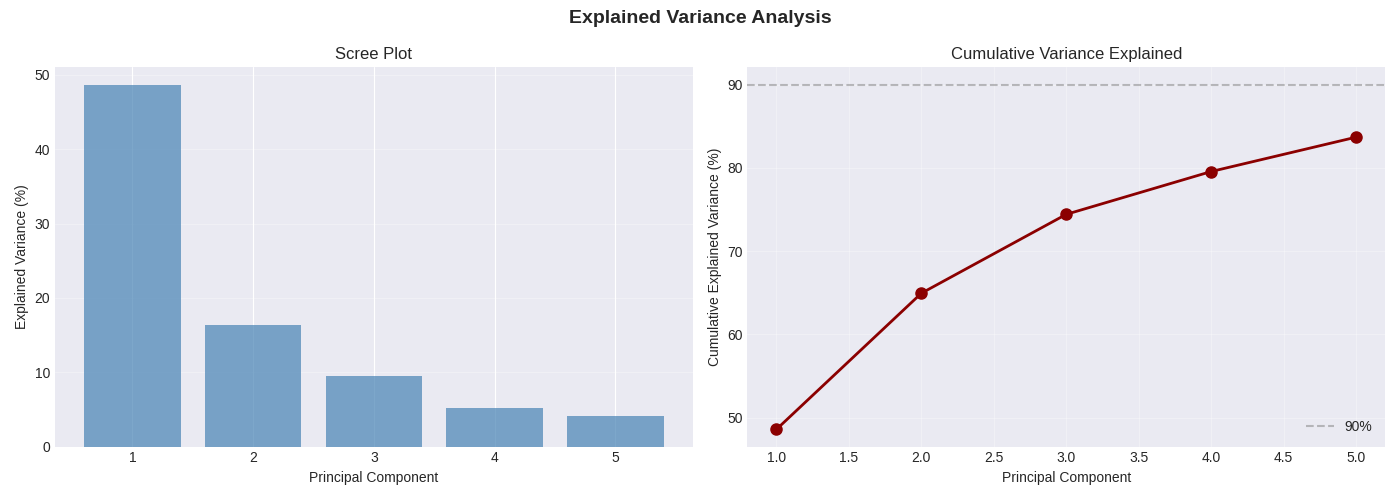

In [22]:
# Plot explained variance
fpca.plot_explained_variance(title='Explained Variance Analysis')
plt.show()

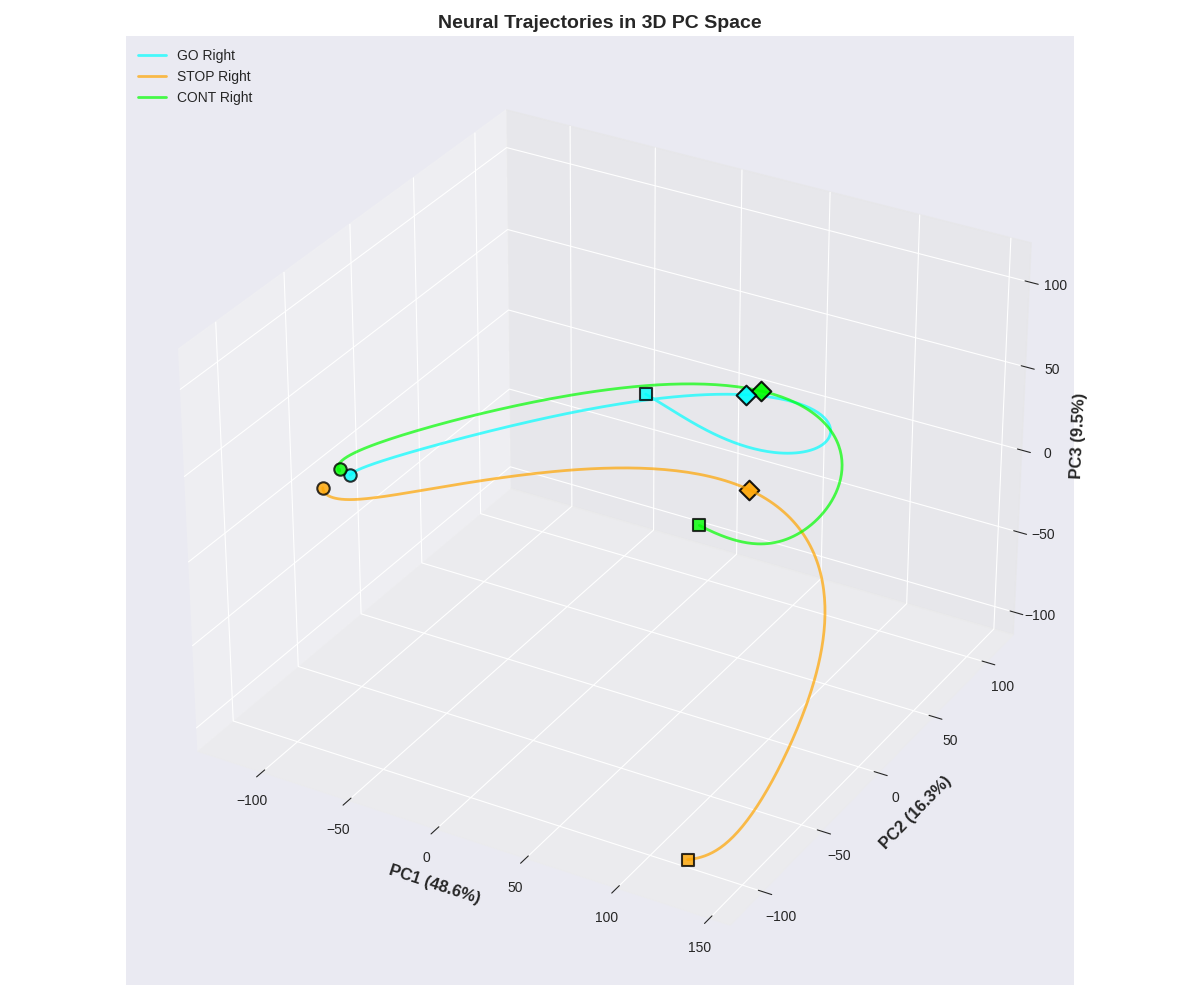

In [26]:
# Plot 3D trajectories (mean SSD marker added automatically)
fpca.plot_3d_trajectories(
    trajectories,
    time_axes,
    title='Neural Trajectories in 3D PC Space',
    figsize=(12, 10)
)
plt.show()

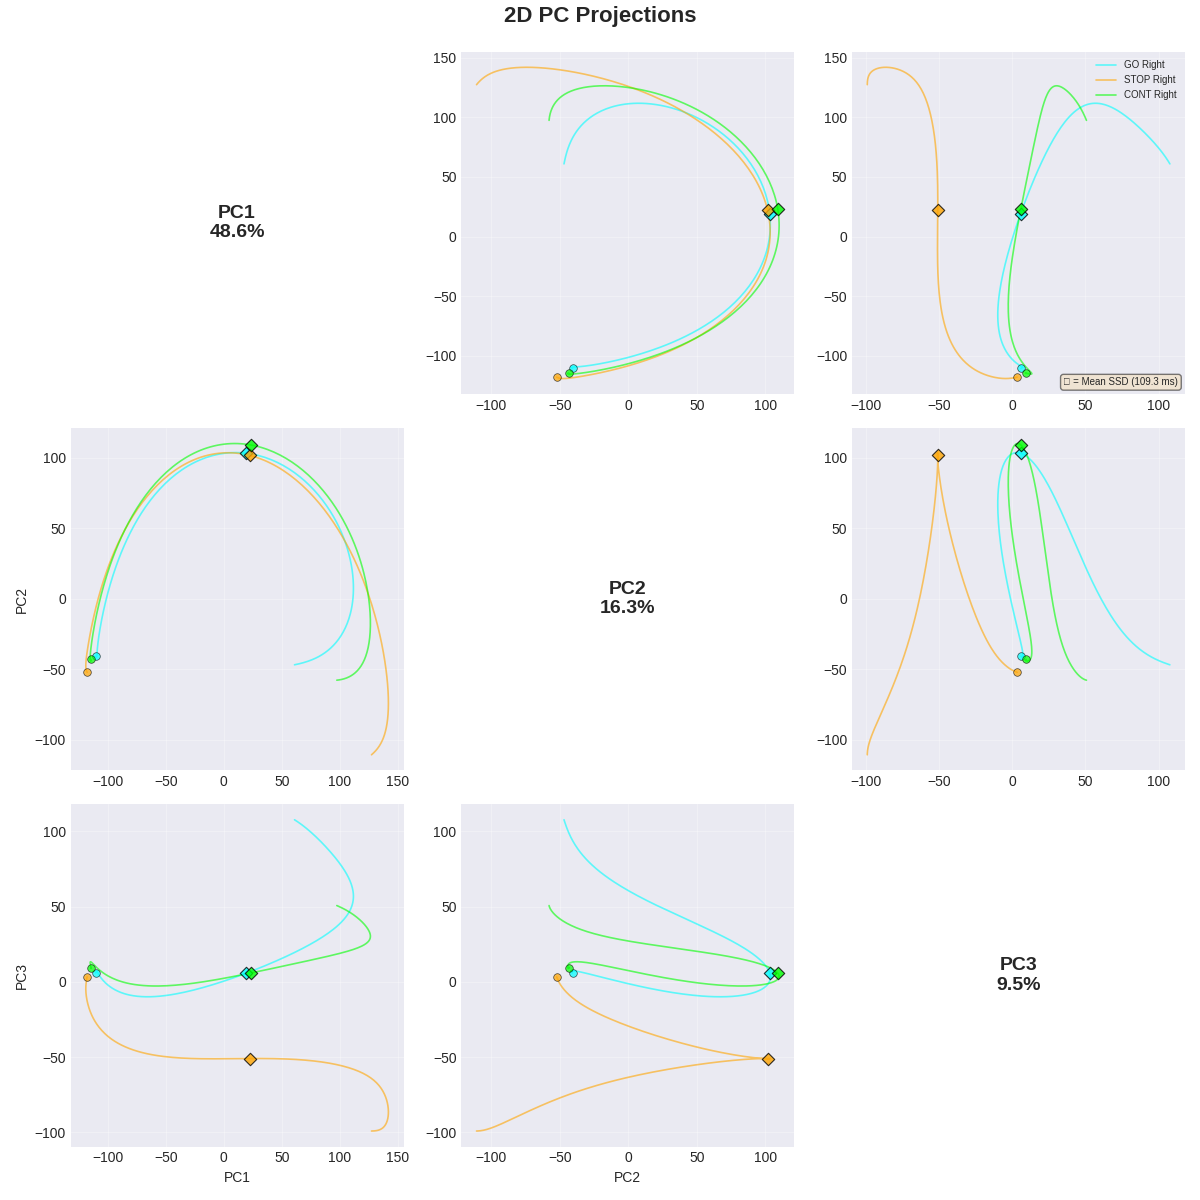

In [27]:
# Plot 2D projections matrix (mean SSD marker added automatically)
fpca.plot_2d_projections(
    trajectories,
    time_axes,
    n_pcs=3,
    title='2D PC Projections',
    figsize=(12, 12)
)
plt.show()

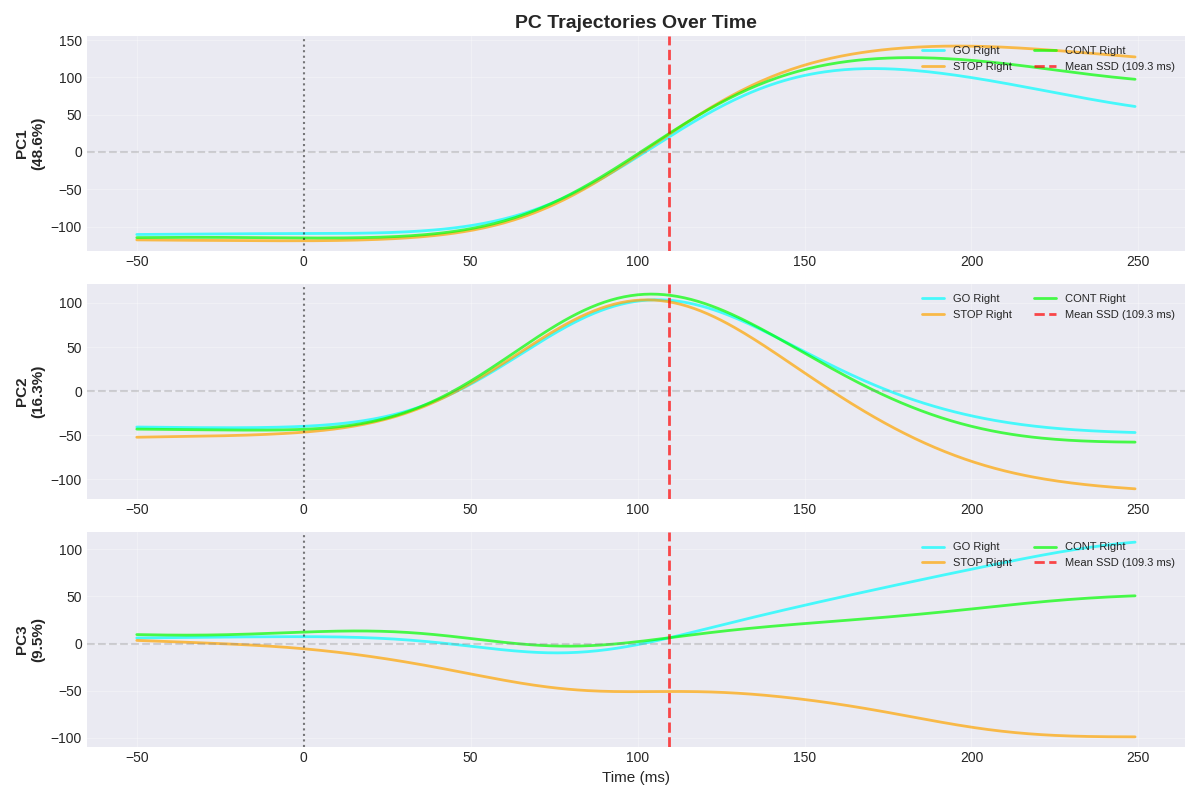

In [25]:
# Plot PC time series (mean SSD marker added automatically)
fpca.plot_pc_timeseries(
    trajectories,
    time_axes,
    n_pcs=3,
    title='PC Trajectories Over Time',
    figsize=(12, 8)
)
plt.show()